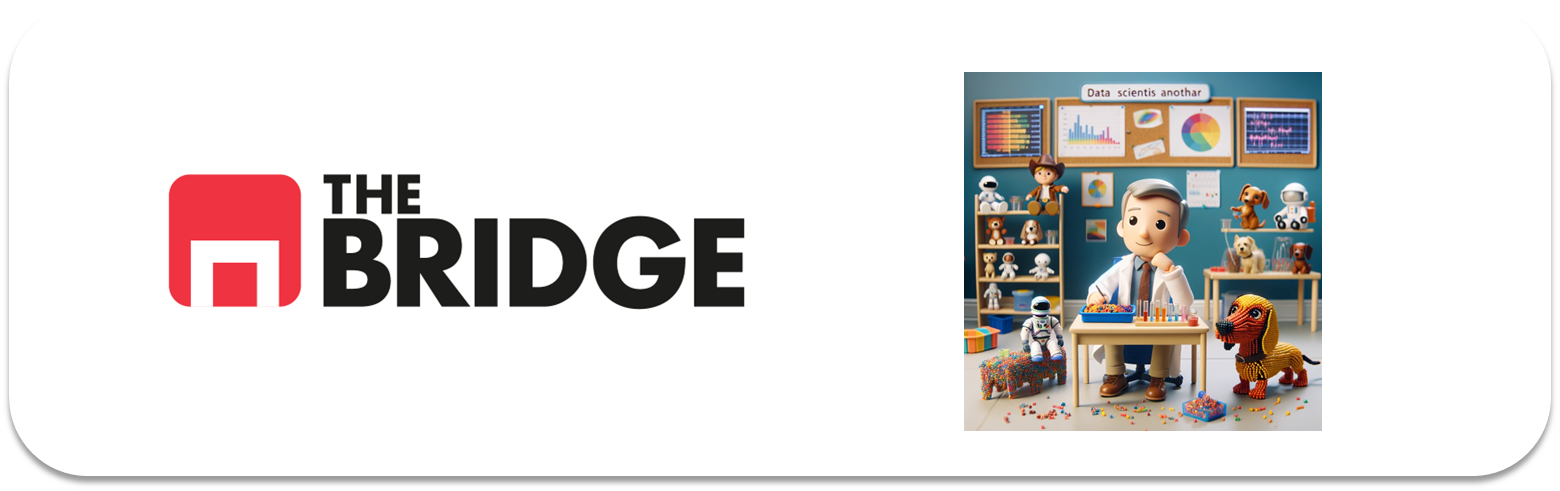

## PRACTICA OBLIGATORIA: **Análisis Univariante**

* La práctica obligatoria de esta unidad consiste en hacer el análisis univariante completo de un dataset con el que acabarás muy familiarizado, el manifiesto de pasajeros del Titanic. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [2]:
sns.get_dataset_names()
df_titanic = sns.load_dataset("titanic")

### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [3]:
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [5]:
df_titanic.drop(columns=["parch"],inplace=True)

In [6]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  deck         203 non-null    category
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(3), object(5)
memory usage: 73.7+ KB


In [7]:
# Porcentaje de nulos por columna:
print((df_titanic.isnull().sum() / len(df_titanic)) * 100)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


Borramos la columna "deck": Tiene más de un 77% de nulos y no es crítica para el análisis.

In [8]:
df_titanic.drop(columns=["deck"],inplace=True)

In [9]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   embarked     889 non-null    object  
 7   class        891 non-null    category
 8   who          891 non-null    object  
 9   adult_male   891 non-null    bool    
 10  embark_town  889 non-null    object  
 11  alive        891 non-null    object  
 12  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(3), object(5)
memory usage: 72.5+ KB


In [10]:
# Porcentaje de nulos por fila:
print((df_titanic.isnull().sum(axis=1) / len(df_titanic.columns)) * 100)

0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.000000
         ...   
886    0.000000
887    0.000000
888    7.692308
889    0.000000
890    0.000000
Length: 891, dtype: float64


In [11]:
df_titanic

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [20]:
df_titanic = df_titanic.dropna(subset=['embark_town'])

In [21]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    object  
 3   age          712 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   fare         889 non-null    float64 
 6   class        889 non-null    category
 7   who          889 non-null    object  
 8   adult_male   889 non-null    bool    
 9   embark_town  889 non-null    object  
 10  alive        889 non-null    object  
 11  alone        889 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(3), object(4)
memory usage: 72.2+ KB


In [22]:
df_titanic.groupby(["sex", "class"])["age"].mean().astype(int)

C:\Users\Arrate\AppData\Local\Temp\ipykernel_15652\42078375.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_titanic.groupby(["sex", "class"])["age"].mean().astype(int)


sex     class 
female  First     34
        Second    28
        Third     21
male    First     41
        Second    30
        Third     26
Name: age, dtype: int64

In [23]:
df_titanic = df_titanic.copy()

In [24]:
df_titanic['age'] = df_titanic.groupby(['sex', 'class'], observed=True)['age'].transform(
    lambda x: x.fillna(x.mean()))

In [25]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    object  
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   fare         889 non-null    float64 
 6   class        889 non-null    category
 7   who          889 non-null    object  
 8   adult_male   889 non-null    bool    
 9   embark_town  889 non-null    object  
 10  alive        889 non-null    object  
 11  alone        889 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(3), object(4)
memory usage: 72.2+ KB


In [26]:
df_titanic['age'] = df_titanic['age'].astype(int)

In [27]:
df_titanic.age.info()

<class 'pandas.core.series.Series'>
Index: 889 entries, 0 to 890
Series name: age
Non-Null Count  Dtype
--------------  -----
889 non-null    int64
dtypes: int64(1)
memory usage: 13.9 KB


### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.


In [28]:
df_titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'fare', 'class', 'who',
       'adult_male', 'embark_town', 'alive', 'alone'],
      dtype='object')

In [29]:
df_titanic.head(20)

,survived,pclass,sex,age,sibsp,fare,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22,1,7.2500,Third,man,True,Southampton,no,False
1,1,1,female,38,1,71.2833,First,woman,False,Cherbourg,yes,False
2,1,3,female,26,0,7.9250,Third,woman,False,Southampton,yes,True
3,1,1,female,35,1,53.1000,First,woman,False,Southampton,yes,False
4,0,3,male,35,0,8.0500,Third,man,True,Southampton,no,True
5,0,3,male,26,0,8.4583,Third,man,True,Queenstown,no,True
6,0,1,male,54,0,51.8625,First,man,True,Southampton,no,True
7,0,3,male,2,3,21.0750,Third,child,False,Southampton,no,False
8,1,3,female,27,0,11.1333,Third,woman,False,Southampton,yes,False
9,1,2,female,14,1,30.0708,Second,child,False,Cherbourg,yes,False




| Columna/Variable | Descripción |
| ---------------- | ----------- |
|survived     | supervievencia si = 1, no = 0. Es igual que la columna alive (cambia el tipo de dato). Binario, int|
|pclass| clase del camarote en número. Es igual que la columna class (cambia el tipo de dato). Int|
|sex| género, binario male, female. Object|
|age| edad del pasajero. Int|
|sibsp| Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros). Int|
|fare| precio del billete. Float|
|class| (= pclass) clase del camarote, categoria|
|who| edad/sexo del pasajero según tres valores man, woman, child. Object|
|adult_male| Booleano, según se cumple o no que el pasajero sea un hombre adulto|
|embark_town|Ciudad de embarque: 'Southampton', 'Cherbourg', 'Queenstown'. Object|
|alive| Superviviente, respuesta binaria: yes, no. Object|
|alone| Solo, respuesta booleana|



In [30]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    object  
 3   age          889 non-null    int64   
 4   sibsp        889 non-null    int64   
 5   fare         889 non-null    float64 
 6   class        889 non-null    category
 7   who          889 non-null    object  
 8   adult_male   889 non-null    bool    
 9   embark_town  889 non-null    object  
 10  alive        889 non-null    object  
 11  alone        889 non-null    bool    
dtypes: bool(2), category(1), float64(1), int64(4), object(4)
memory usage: 72.2+ KB


### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [15]:
df_titanic["embark_town"].unique()

array(['Southampton', 'Cherbourg', 'Queenstown', nan], dtype=object)

In [16]:
df_titanic["embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [17]:
mapeo = {
    'S': 'Southampton',
    'C': 'Cherbourg',
    'Q': 'Queenstown',
    'nan': 'nan'
}
df_trac_embarked = df_titanic["embarked"].map(mapeo)


respuesta = df_trac_embarked.equals(df_titanic.embark_town)

# Si uso el comparador == , al comparar 'nan' == 'nan' da siempre False

In [18]:
respuesta

True

Como 'embarked' es igual a 'embark_town', borro la primera y me quedo con la segunda que tiene el nombre de las ciudades.

In [19]:
df_titanic.drop(columns=["embarked"],inplace=True)

### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

### #2.1 Categóricas

In [31]:
columnas_categoricas = ['sex', 'class', 'who',           # class, who, embark_town, alone.
       'adult_male', 'embark_town', 'alive', 'alone']

In [32]:
from bootcampviztools import pinta_distribucion_categoricas

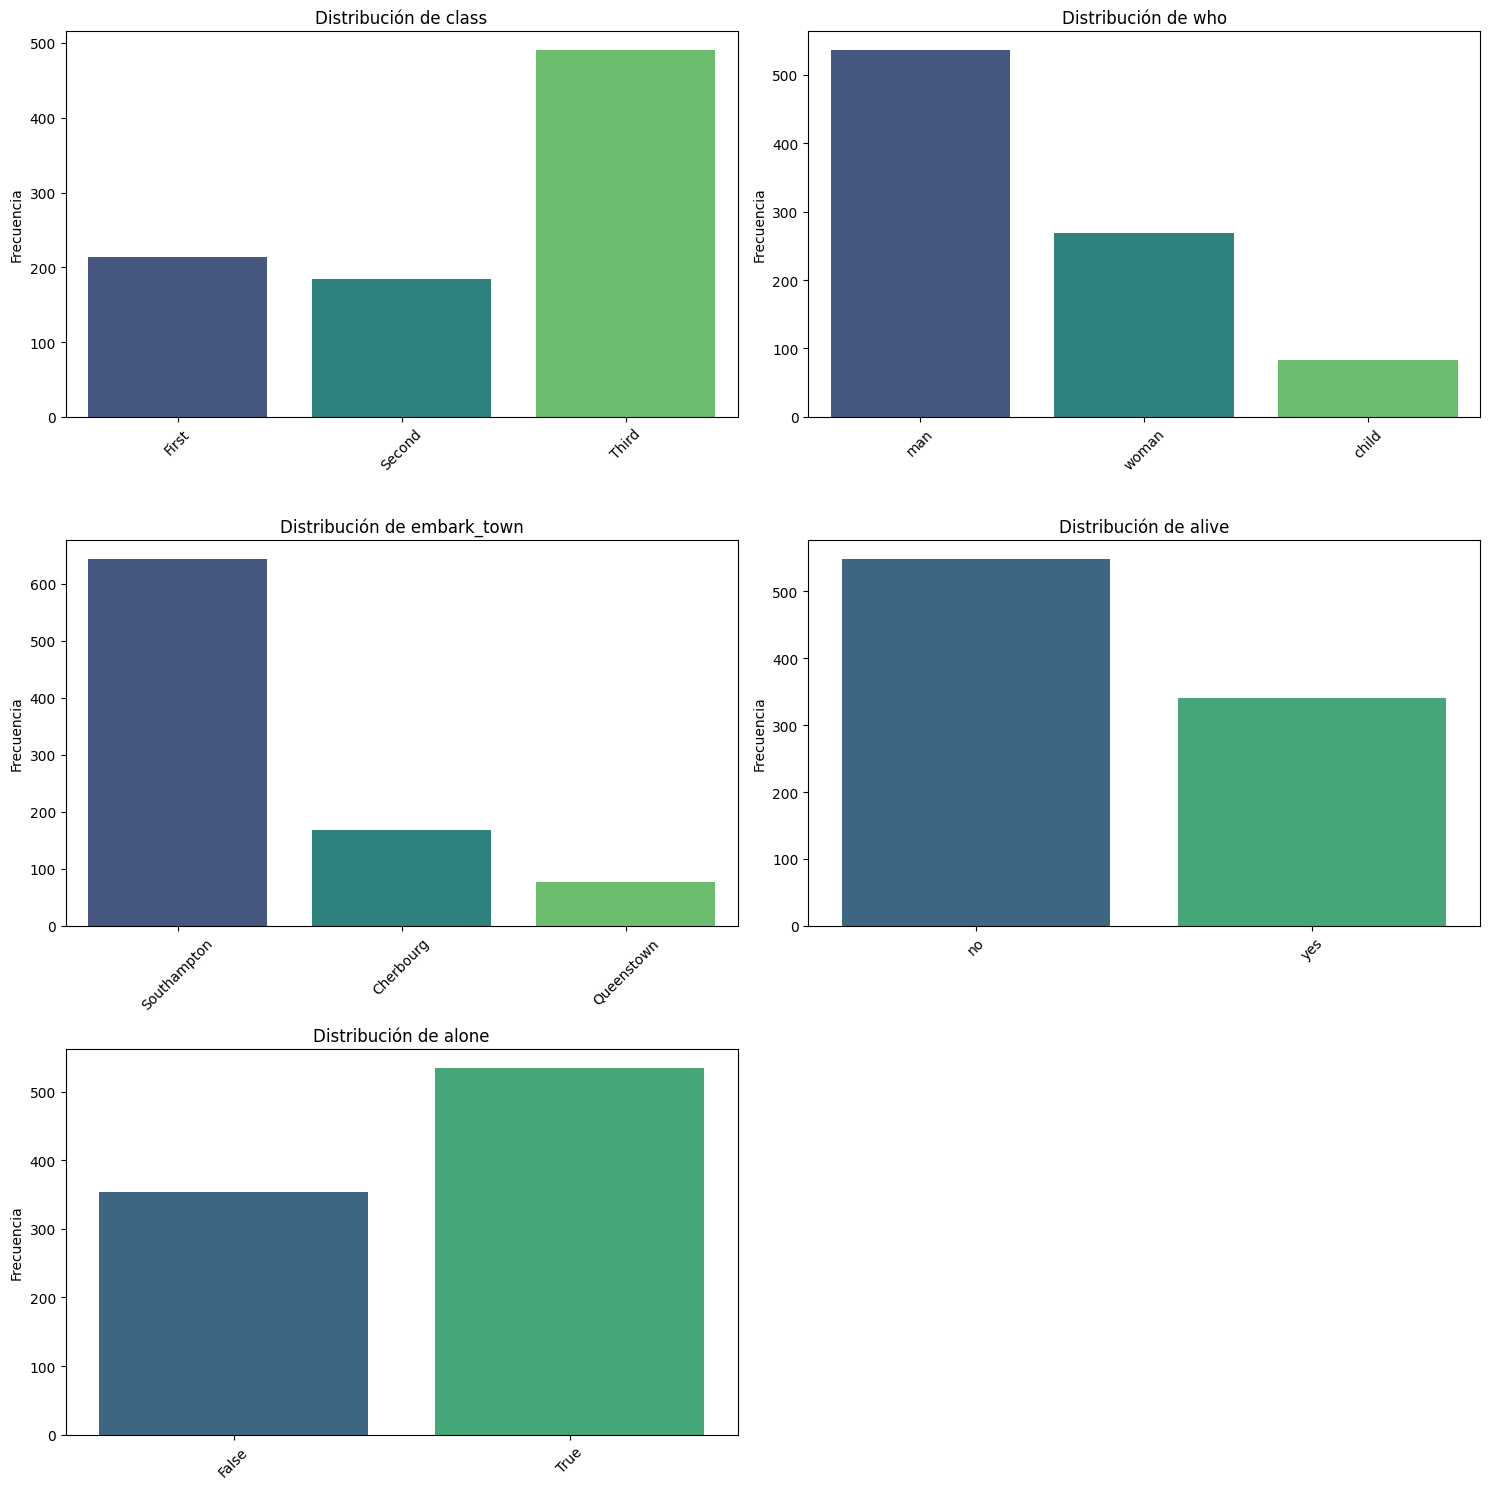

In [36]:
pinta_distribucion_categoricas(df_titanic, ["class", "who","embark_town","alive","alone"])

In [37]:
variables_categoricas = ["class", "who","embark_town","alive","alone"]
for catego in variables_categoricas:
    print(f"Para {catego} sus frecuencias absolutas son:")
    print(df_titanic[catego].value_counts())
    print("\n")

Para class sus frecuencias absolutas son:
class
Third     491
First     214
Second    184
Name: count, dtype: int64


Para who sus frecuencias absolutas son:
who
man      537
woman    269
child     83
Name: count, dtype: int64


Para embark_town sus frecuencias absolutas son:
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


Para alive sus frecuencias absolutas son:
alive
no     549
yes    340
Name: count, dtype: int64


Para alone sus frecuencias absolutas son:
alone
True     535
False    354
Name: count, dtype: int64




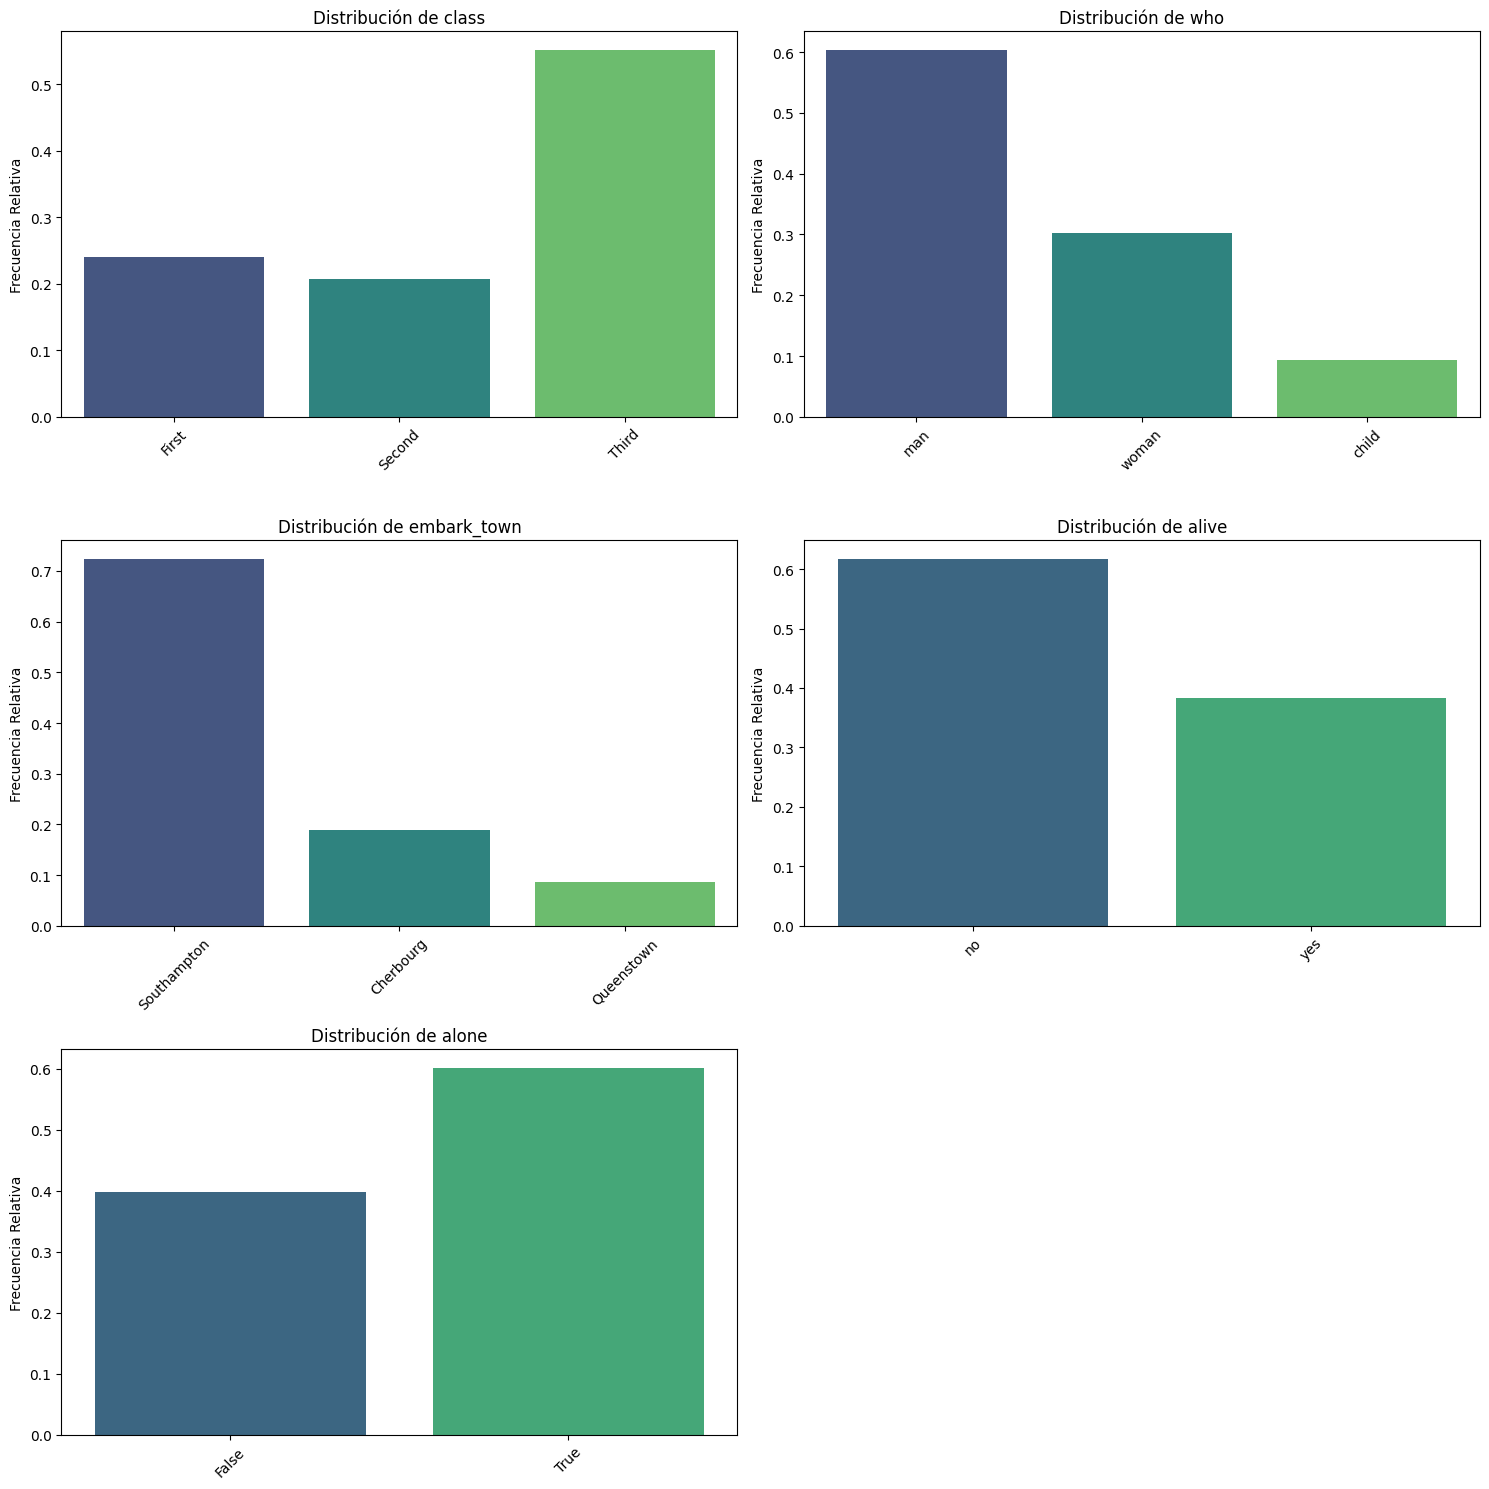

In [38]:
pinta_distribucion_categoricas(df_titanic, ["class", "who","embark_town","alive","alone"], relativa=True)

In [39]:
variables_categoricas = ["class", "who","embark_town","alive","alone"]
for catego in variables_categoricas:
    print(f"Para {catego} sus frecuencias absolutas son:")
    print((df_titanic[catego].value_counts() / len(df_titanic)) * 100)
    print("\n")

Para class sus frecuencias absolutas son:
class
Third     55.230596
First     24.071991
Second    20.697413
Name: count, dtype: float64


Para who sus frecuencias absolutas son:
who
man      60.404949
woman    30.258718
child     9.336333
Name: count, dtype: float64


Para embark_town sus frecuencias absolutas son:
embark_town
Southampton    72.440945
Cherbourg      18.897638
Queenstown      8.661417
Name: count, dtype: float64


Para alive sus frecuencias absolutas son:
alive
no     61.754781
yes    38.245219
Name: count, dtype: float64


Para alone sus frecuencias absolutas son:
alone
True     60.179978
False    39.820022
Name: count, dtype: float64




* La mayoría del pasaje erán hombres adultos, más de 60%
* Viajaba en tercera clase, más de 55%
* Se embarcó en Southampton, más del 72%
* Y más de la mitad viajaba solo,  60%
* Y un 61,75 % no sobrevivió.

In [40]:
df_titanic[variables_categoricas].mode().T

,0
class,Third
who,man
embark_town,Southampton
alive,no
alone,True


Como primera hipotesís, sin ser definitiva, podemos decir que el pasajero tipo fué un hombre adulto que viajó en tercera clase, embarcó en Southampton, viajaba solo y no sobrevivio.

In [45]:
print(df_titanic["survived"].value_counts() / len(df_titanic))
print((df_titanic["survived"].value_counts() / len(df_titanic)) * 100)

survived
0    0.617548
1    0.382452
Name: count, dtype: float64
survived
0    61.754781
1    38.245219
Name: count, dtype: float64


Survived nos da la misma información que alive.

### #2.2 Numéricas

In [48]:
columnas_numericas= df_titanic.describe().T.index.to_list()
columnas_numericas
# survived, age, fare 

['survived', 'pclass', 'age', 'sibsp', 'fare']

In [49]:
def calculo_cv(df):
    df_cv = df.describe().loc[["std","mean"]].T
    df_cv["CV"]= (df_cv["std"] / df_cv["mean"]) *100
    return df_cv

In [50]:
print(df_titanic[['age', 'sibsp', 'fare']].describe())

              age       sibsp        fare
count  889.000000  889.000000  889.000000
mean    29.145107    0.524184   32.096681
std     13.279662    1.103705   49.697504
min      0.000000    0.000000    0.000000
25%     21.000000    0.000000    7.895800
50%     26.000000    0.000000   14.454200
75%     36.000000    1.000000   31.000000
max     80.000000    8.000000  512.329200


In [52]:
# Rango
print(df_titanic[['age', 'sibsp', 'fare']].describe().loc["max"] - df_titanic[['age', 'sibsp', 'fare']].describe().loc["min"])

age       80.0000
sibsp      8.0000
fare     512.3292
dtype: float64


In [55]:
print(calculo_cv(df_titanic[['age', 'sibsp', 'fare']]))

             std       mean          CV
age    13.279662  29.145107   45.563949
sibsp   1.103705   0.524184  210.556574
fare   49.697504  32.096681  154.836896


¿Como se relaciona sibsp con el estatus de clase?  
¿Como es posible que en age, el mínimo sea 0? ¿Bebés de menos de un año?
Los datos tienen una gran dispersión.  
Los histogramas tienen largas colas y las boxplot muestran bastantes outliers, corrobora la dispersión de los datos.
La mayoría de los pasajeros eran adultos jóvenes entre 21 y 36 años, como muestran los cuartiles.  
Como hemos comprobado antes la mayoría viajaba solo, aunque hay un numero de grupos (imagino que familias) a tener en cuenta.  
En tercera es donde viajaba la mayoría como se ve por el número de tarifas más economicas que refleja el histograma fare, podemos ver en el boxplot una serie de outliers que muestran unas tarifas con un importe altisimo comparado con la tarifa económica.

In [56]:
from bootcampviztools import plot_combined_graphs

(3, 2)


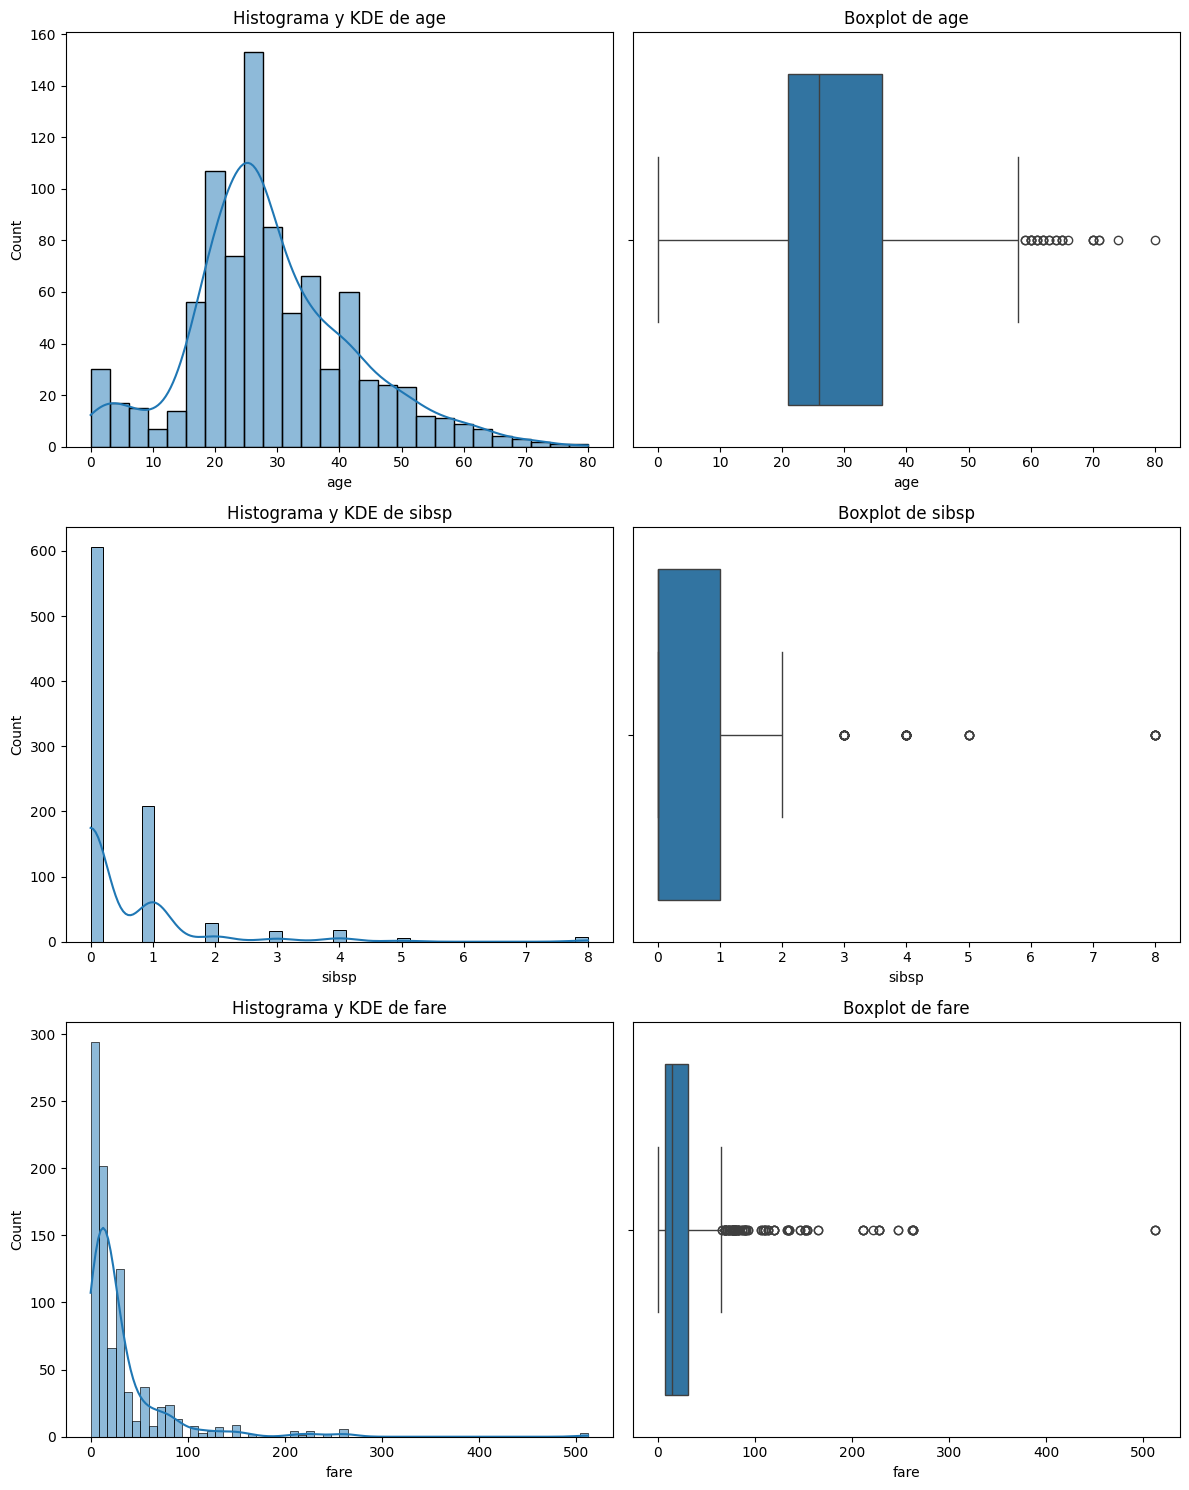

In [57]:
plot_combined_graphs(df_titanic,['age', 'sibsp', 'fare'])